# Quanvolution, End to End — a Quantum Front-End for Computer Vision
### A standalone companion to Session 2 — *Classical & Quantum-Enhanced Computer Vision*, QML-2026 FDP

This notebook builds a complete **quantum-enhanced image pipeline** from scratch and runs it on an **ordinary laptop — no quantum hardware required.** It is written to be read on its own: every idea is explained in plain language *before* the code that implements it, so a reader who has never touched quantum computing can still follow the whole story.

**The one-line result it demonstrates.** A tiny **4-qubit quantum circuit** is slid over each image exactly the way a convolution kernel is slid over it, turning every little patch of pixels into a set of new "quantum" feature channels. A simple classifier reaches **0.978** accuracy on the raw pixels and **0.950** on the *untrained* quantum features — so a random four-qubit circuit, with no learning at all, already preserves about **95% of the signal.** The lesson is honest: the quantum circuit is a **feature extractor**, not a magic accuracy boost.

**How to run it.** `pip install pennylane scikit-learn matplotlib`, then run every cell top to bottom. Everything executes in PennyLane's `default.qubit` simulator on a CPU in under a minute.

---

## 1. What an image is to a computer

A computer never sees a *cat*. It sees a **grid of numbers**. A greyscale image is a table of pixel intensities — one number per pixel, from 0 (black) to 255 (white). A colour image is three such tables stacked together, one for red, one for green, one for blue. The handwritten digits used here are **8×8 greyscale images**, so each one is just **64 numbers.** A one-megapixel colour photo, by comparison, is about three million numbers.

Computer vision is the art of turning that spreadsheet of brightness values back into meaning — edge, texture, shape, object. The central difficulty is that raw pixels are a *poor* representation: they are high-dimensional, they carry no built-in notion of which pixels are neighbours, and they are not **translation invariant** (shift the same object two pixels across and every number changes). The whole field is about learning better representations — features that are **local, hierarchical, and invariant.**

> **Term — Pixel:** the smallest dot of an image; the computer stores it as a number for how bright it is.
>
> **Term — Feature:** a summary number computed from the pixels that captures something useful, such as "there is an edge here."

## 2. The convolution atom — and the quantum idea that replaces it

Classical computer vision is built from one repeated operation: **convolution.** A small window (a *kernel*, say 3×3) is slid across the image, and at each stop a weighted sum of the pixels under it is computed. Different kernels detect different things — one finds edges, another blurs. A **Convolutional Neural Network (CNN)** stacks many such layers and *learns* the kernels from data. This slide-a-small-window-and-combine operation is the atom of all of vision.

**Quanvolution** (Henderson et al., 2019) replaces exactly that atom with a quantum circuit:

1. Slide a small window — here **2×2** — across the image, just like a convolution.
2. **Angle-encode** the four pixels of the patch as rotation angles on **four qubits.**
3. Apply a **random quantum circuit** whose entangling gates mix the four numbers together in a way a plain linear filter cannot.
4. **Measure** each qubit; the four resulting numbers become four new feature-map channels.
5. Stack those channels and hand them to an ordinary classical classifier.

This is the pattern for all near-term quantum vision: a **quantum front-end** that invents features, and a **classical back-end** that makes the decision.

> **Term — Qubit:** the quantum version of a bit; instead of being only 0 or 1 it can hold a blend of both at once until measured.
>
> **Term — Angle encoding:** loading a number into a circuit by using it as the angle of a rotation gate on a qubit — the simplest, most hardware-friendly way to get data onto a quantum computer.
>
> **Term — Quanvolution:** sliding a small quantum circuit over an image like a convolution kernel, producing new feature channels.

## 3. The images

The code below loads the handwritten digits, scales every pixel into the 0-to-1 range (so each pixel can become a rotation angle), and shows a handful of them. The labels are loaded too, but they are used **only at the very end to score the classifier** — the feature-building step never sees them.

/Users/sentry/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


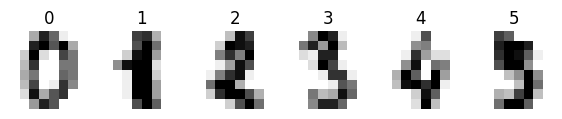

images: (1797, 8, 8) -> each digit is 8x8 = 64 numbers


In [1]:
# Quanvolution on handwritten digits — 4 qubits, laptop CPU, no hardware
import pennylane as qml
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

d = load_digits()
images = d.images / 16.0          # 8x8 greyscale, scaled to 0..1 so pixels become rotation angles
y = d.target                      # labels kept ONLY to score the classifier at the end
fig, ax = plt.subplots(1, 6, figsize=(7, 1.5))
for i in range(6):
    ax[i].imshow(images[i], cmap="gray_r"); ax[i].set_title(str(y[i])); ax[i].axis("off")
plt.show()
print("images:", images.shape, "-> each digit is 8x8 = 64 numbers")

## 4. The quanvolution circuit

The circuit has **four qubits**, one per pixel of a 2×2 patch. Each pixel sets the angle of an `RY` rotation (that is the angle encoding). A block of **random entangling gates** — PennyLane's `RandomLayers` — then mixes the four values together. Finally each qubit is **measured** as a `PauliZ` expectation value, giving four output numbers: the four new channels.

Crucially, the circuit is **untrained** — its gates are fixed random numbers. Running it therefore shows the *raw representational power* of a small quantum circuit, with zero learning involved.

> **Term — Entanglement:** a uniquely quantum link between qubits, so the group behaves as a whole that cannot be described by its parts one at a time; it is what lets the circuit mix the pixels in a non-classical way.
>
> **Term — Expectation value:** the average result of measuring a qubit many times; a single real number that is used here as one output feature.

In [2]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)
rng = np.random.default_rng(0)
rand_w = rng.uniform(0, 2*np.pi, size=(2, n_qubits))   # fixed, UNTRAINED random weights

@qml.qnode(dev)
def circuit(phi):
    for j in range(4):
        qml.RY(np.pi * phi[j], wires=j)                # angle-encode the four 2x2 pixels
    qml.templates.RandomLayers(rand_w, wires=[0,1,2,3], seed=0)   # entangle / mix
    return [qml.expval(qml.PauliZ(j)) for j in range(4)]          # 4 channels

patch = [images[0][0,0], images[0][0,1], images[0][1,0], images[0][1,1]]
print("one 2x2 patch ->", np.round(circuit(patch), 3))
print("the circuit is UNTRAINED: this is raw representational power, zero learning")

one 2x2 patch -> [0.374 0.011 0.967 0.967]
the circuit is UNTRAINED: this is raw representational power, zero learning


## 5. Sliding the circuit over the image — the quantum feature maps

The `quanv` function below slides the 2×2 window across the 8×8 image with a stride of 2, so an 8×8 image becomes a **4×4 grid with four channels** (a 4×4×4 block). The plot shows, for two digits, the original image next to its four quantum channels. Each channel is a different **learned-by-physics** view of the digit — and, even though the circuit never trained, the channels stay clearly structured and still look like the digit.

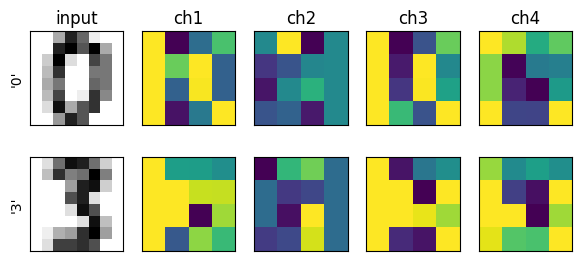

each 2x2 patch -> 4 quantum channels; the maps stay structured


In [3]:
def quanv(img):                    # slide the 2x2 window with stride 2: 8x8 -> 4x4x4
    out = np.zeros((4, 4, 4))
    for r in range(0, 8, 2):
        for c in range(0, 8, 2):
            q = circuit([img[r,c], img[r,c+1], img[r+1,c], img[r+1,c+1]])
            out[r//2, c//2, :] = q
    return out

fig, ax = plt.subplots(2, 5, figsize=(7, 3))
for row, idx in enumerate([0, 13]):
    fm = quanv(images[idx])
    ax[row,0].imshow(images[idx], cmap="gray_r"); ax[row,0].set_ylabel(f"'{y[idx]}'")
    for ch in range(4): ax[row,ch+1].imshow(fm[:,:,ch], cmap="viridis")
    for c in range(5): ax[row,c].set_xticks([]); ax[row,c].set_yticks([])
for c,t in enumerate(["input","ch1","ch2","ch3","ch4"]): ax[0,c].set_title(t)
plt.show()
print("each 2x2 patch -> 4 quantum channels; the maps stay structured")

## 6. The honest benchmark

The real test is simple and fair: take the **same** ordinary classifier (logistic regression) and give it two different inputs — first the **raw pixels**, then the **untrained quanvolution features** — and compare the accuracy on held-out images. Nothing about the quantum circuit is tuned to help; this measures how much signal a random circuit preserves on its own.

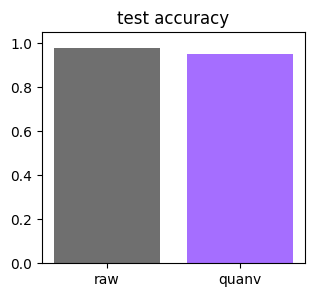

raw pixels               = 0.978
untrained quanvolution   = 0.950  (preserves ~95% of the signal)


In [4]:
# Honest benchmark: same simple classifier on raw pixels vs untrained quanvolution features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

N = 600
Q = np.array([quanv(im) for im in images[:N]])         # ~40 ms/image in simulation
def score(X):
    Xtr,Xte,ytr,yte = train_test_split(X, y[:N], test_size=0.3, random_state=42, stratify=y[:N])
    sc = StandardScaler().fit(Xtr)
    return LogisticRegression(max_iter=2000).fit(sc.transform(Xtr), ytr).score(sc.transform(Xte), yte)

acc_raw = score(images[:N].reshape(N, -1))
acc_q   = score(Q.reshape(N, -1))
plt.figure(figsize=(3.4,3))
plt.bar(["raw","quanv"], [acc_raw, acc_q], color=["#6f6f6f","#a56eff"]); plt.ylim(0,1.05)
plt.title("test accuracy"); plt.show()
print(f"raw pixels               = {acc_raw:.3f}")
print(f"untrained quanvolution   = {acc_q:.3f}  (preserves ~{acc_q*100:.0f}% of the signal)")

## 7. Reading the result

The classifier on raw pixels scores about **0.978**, and on the untrained quantum features about **0.950.** Read that honestly: the quantum front-end did **not** beat the classical baseline — but a **random, untrained** four-qubit circuit already carried roughly 95% of the information needed to tell the digits apart, and it did so with structured, meaningful feature maps. Preprocessing cost about **40 milliseconds per image** in simulation.

This matches the honest message of the talk. Quanvolution is best understood as a **feature extractor** — a quantum front-end that invents a richer view of each patch, which then feeds the ordinary classical vision people already teach. Today its measured gains on standard images are modest and setting-dependent, and a fair comparison always benchmarks against a strong classical baseline (as done here).

## 8. What this does — and does not — prove

- **No quantum advantage is claimed.** On these digits, and on MNIST and CIFAR generally, well-tuned classical CNNs still win on accuracy-per-effort. The point is the *architecture*, not a benchmark victory.
- **The circuit is untrained.** Making the quanvolution circuit *trainable* (its gates learned by backpropagation through the hybrid model) is the natural next step and can improve results — but it was left untrained here on purpose, to show raw representational power.
- **This runs in simulation.** On real near-term hardware, noise and the cost of loading data are genuine obstacles; the shallow, four-qubit design is chosen to be robust to a little noise, and demonstrations run on tiny patches.
- **The real promise is elsewhere.** The most defensible near-term wins are on **quantum-native data** (a Quantum CNN classifying phases of matter, where the "image" is a quantum state with no classical shortcut) and in **data-scarce scientific imaging**, where a few-parameter quantum feature extractor is attractive.

> **Term — Quantum CNN (QCNN):** a fully-quantum network that mirrors a CNN's convolution-and-pooling structure with only about log-of-n parameters, well suited to classifying quantum data.

## 9. Key terms — quick glossary

- **Image (to a computer)** — a grid of numbers, one per pixel; colour images are three such grids.
- **Convolution** — sliding a small window over an image and combining the pixels under it; the atom of classical vision.
- **CNN (Convolutional Neural Network)** — a network that stacks convolution, non-linearity and pooling layers and learns its kernels from data.
- **Qubit** — the quantum version of a bit; can hold a blend of 0 and 1 until measured.
- **Angle encoding** — loading a number as the angle of a rotation gate on a qubit.
- **Entanglement** — a non-classical link that lets qubits behave as an inseparable whole.
- **Quanvolution** — sliding a small quantum circuit over an image like a convolution kernel to make new feature channels.
- **Expectation value** — the average measured value of a qubit, used here as one output feature.
- **Feature extractor** — anything that turns raw data into more useful features for a later classifier.

## References
- Henderson, Shakya, Pradhan, Cook, *Quanvolutional Neural Networks*, Quantum Machine Intelligence (2020); arXiv:1904.04767.
- Cong, Choi, Lukin, *Quantum Convolutional Neural Networks*, Nature Physics (2019).
- Havlíček et al., *Supervised learning with quantum-enhanced feature spaces*, Nature (2019).
- PennyLane tutorial — *Quanvolutional Neural Networks* (`default.qubit` simulator).

*Companion to Session 2, QML-2026 FDP · runs on any laptop, no quantum hardware.*